
Ni_08-09-26
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)      ± uncertainty
-------------------------------------------------------------------------------------
   1    44.4819   ±  0.0011         2714    2.03512   ± 0.00005
   2    51.8330   ±  0.0023          882    1.76246   ± 0.00007
   3    76.3993   ±  0.0041          370    1.24563   ± 0.00006
   4    92.9684   ±  0.0059          275    1.06221   ± 0.00005
   5    98.4832   ±  0.0109           94    1.01694   ± 0.00008

Goodness of fit:
χ² = 3653.45
Degrees of freedom = 1984
Reduced χ² = 1.841

Ni_10-09-26
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)      ± uncertainty
-------------------------------------------------------------------------------------
   1    44.4843   ±  0.0011         2384    2.03502   ± 0.00005
   2    51.8331   ±  0.0024          786    1.76245   ± 0.00008
   3    76.3933   ±  0.0045          320    1.24571   ± 0.00006
   4    92.9701   ±  0.0062          247    1.06220   ± 

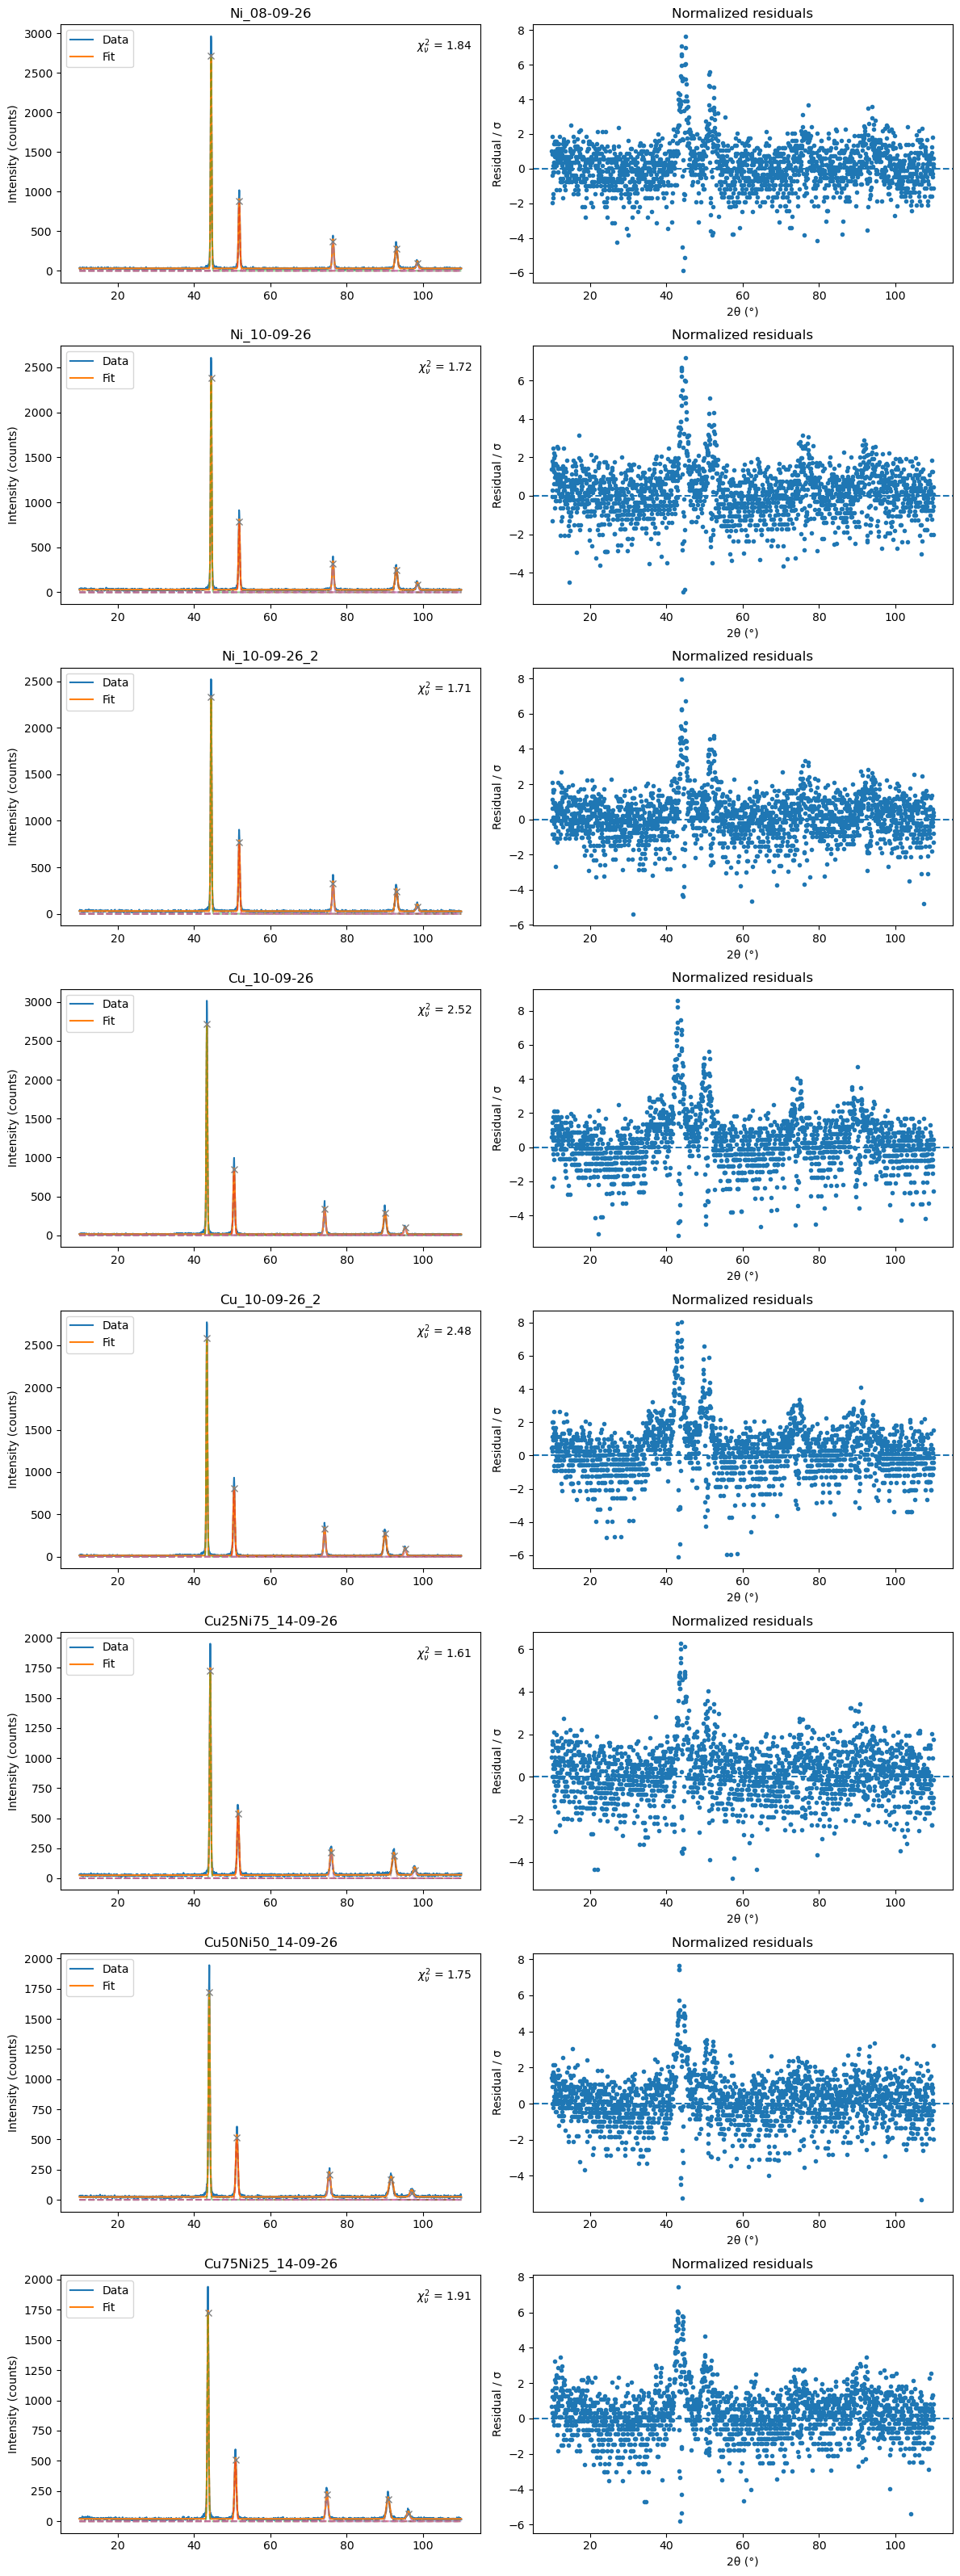

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# List of files
files = [
    "XRD_data/Ni_08-09-26.UXD",
    "XRD_data/Ni_10-09-26.UXD",
    "XRD_data/Ni_10-09-26_2.UXD",
    "XRD_data/Cu_10-09-26.UXD",
    "XRD_data/Cu_10-09-26_2.UXD",
    "XRD_data/Cu25Ni75_14-09-26.UXD",
    "XRD_data/Cu50Ni50_14-09-26.UXD",
    "XRD_data/Cu75Ni25_14-09-26.UXD",
]

fig, axes = plt.subplots(
    len(files), 2,
    figsize=(12, 4 * len(files))
)

if len(files) == 1:
    axes = np.array([axes])

data_axes = axes[:, 0]
residual_axes = axes[:, 1]

peak_angles = {}
peak_intensities = {}
peak_d = {}
peak_angle_errors = {}
peak_d_errors = {}


# ---------------------------------------------------------
# Gaussian functions
# ---------------------------------------------------------

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


def gaussian_sum(x, *params):

    # First two parameters are the linear background
    m = params[0]
    b = params[1]

    y = m * x + b

    # Remaining parameters are the Gaussian peaks
    for i in range(2, len(params), 3):

        A = params[i]
        mu = params[i + 1]
        sigma = params[i + 2]

        y += gaussian(x, A, mu, sigma)

    return y


# ---------------------------------------------------------
# Bragg's law
# ---------------------------------------------------------

wavelength = 1.5406  # Angstrom, Cu K_alpha
n = 1


for i, file in enumerate(files):

    # -----------------------------------------------------
    # Load data
    # -----------------------------------------------------

    data = np.loadtxt(file)

    twotheta = data[:, 0]
    intensity = data[:, 1]

    # Uncertainty from counting statistics
    intensity_error = np.sqrt(np.maximum(intensity, 1))


    # -----------------------------------------------------
    # Step 1: Find rough peak positions
    # -----------------------------------------------------

    peaks, _ = find_peaks(
        intensity,
        prominence=50
    )

    rough_positions = twotheta[peaks]
    rough_heights = intensity[peaks]


    # -----------------------------------------------------
    # Step 2: Initial guesses
    # -----------------------------------------------------

    initial_guess = [
        0,                  # background slope
        np.min(intensity)   # background intercept
    ]

    for position, height in zip(rough_positions, rough_heights):

        initial_guess.extend([
            height,      # amplitude
            position,    # center
            0.15         # sigma
        ])


    # -----------------------------------------------------
    # Step 3: Bounds
    # -----------------------------------------------------

    lower_bounds = [
        -np.inf,    # background slope
        0           # background intercept
    ]

    upper_bounds = [
        np.inf,
        np.inf
    ]

    for position in rough_positions:

        lower_bounds.extend([
            0,
            position - 1.0,
            0.01
        ])

        upper_bounds.extend([
            np.inf,
            position + 1.0,
            1.0
        ])


    # -----------------------------------------------------
    # Step 4: Fit
    # -----------------------------------------------------

    try:

        popt, pcov = curve_fit(
            gaussian_sum,
            twotheta,
            intensity,
            p0=initial_guess,
            sigma=intensity_error,
            absolute_sigma=True,
            bounds=(lower_bounds, upper_bounds),
            maxfev=50000
        )

        # Parameter uncertainties
        perr = np.sqrt(np.diag(pcov))

        fit_success = True

    except (RuntimeError, ValueError):

        print("Fit failed for:", file)

        fit_success = False


    # -----------------------------------------------------
    # Store fitted peak information
    # -----------------------------------------------------

    name = file.split("/")[-1].replace(".UXD", "")

    if fit_success:

        fitted_angles = []
        fitted_intensities = []
        fitted_d = []
        fitted_angle_errors = []
        fitted_d_errors = []


        # -------------------------------------------------
        # Calculate fit
        # -------------------------------------------------

        fit = gaussian_sum(
            twotheta,
            *popt
        )


        # -------------------------------------------------
        # Calculate residuals
        # -------------------------------------------------

        residuals = intensity - fit

        normalized_residuals = (
            residuals / intensity_error
        )


        # -------------------------------------------------
        # Chi squared
        # -------------------------------------------------

        chi_squared = np.sum(
            (residuals / intensity_error)**2
        )

        N = len(intensity)

        # 2 background parameters + 3 per peak
        n_parameters = len(popt)

        degrees_of_freedom = (
            N - n_parameters
        )

        reduced_chi_squared = (
            chi_squared / degrees_of_freedom
        )


        # -------------------------------------------------
        # Store peak parameters
        # -------------------------------------------------

        for j in range(len(rough_positions)):

            # +2 because the first two parameters
            # are the background slope and intercept
            A = popt[2 + 3*j]
            mu = popt[2 + 3*j + 1]
            sigma = popt[2 + 3*j + 2]

            mu_error = perr[2 + 3*j + 1]


            # ---------------------------------------------
            # Bragg's law
            # ---------------------------------------------

            theta = np.radians(mu / 2)

            d = wavelength / (
                2 * np.sin(theta)
            )

            d_error = (
                wavelength
                / (2 * np.sin(theta)**2)
                * np.cos(theta)
                * (np.radians(mu_error) / 2)
            )


            fitted_angles.append(mu)
            fitted_intensities.append(A)
            fitted_d.append(d)
            fitted_angle_errors.append(mu_error)
            fitted_d_errors.append(d_error)


        peak_angles[name] = np.array(fitted_angles)
        peak_intensities[name] = np.array(fitted_intensities)
        peak_d[name] = np.array(fitted_d)
        peak_angle_errors[name] = np.array(fitted_angle_errors)
        peak_d_errors[name] = np.array(fitted_d_errors)


        # -------------------------------------------------
        # Print results
        # -------------------------------------------------

        print("\n" + "=" * 85)
        print(name)
        print("=" * 85)

        print(
            "Peak   2θ (°)       ± uncertainty     "
            "Intensity       d (Å)      ± uncertainty"
        )

        print("-" * 85)

        for j in range(len(fitted_angles)):

            print(
                f"{j+1:4d}   "
                f"{fitted_angles[j]:8.4f}   "
                f"± {fitted_angle_errors[j]:7.4f}   "
                f"{fitted_intensities[j]:10.0f}   "
                f"{fitted_d[j]:8.5f}"
                f"   ± {fitted_d_errors[j]:7.5f}"
            )


        # -------------------------------------------------
        # Print goodness of fit
        # -------------------------------------------------

        print("\nGoodness of fit:")
        print(f"χ² = {chi_squared:.2f}")
        print(f"Degrees of freedom = {degrees_of_freedom}")
        print(f"Reduced χ² = {reduced_chi_squared:.3f}")


        # -------------------------------------------------
        # Plot original data
        # -------------------------------------------------

        data_axes[i].plot(
            twotheta,
            intensity,
            label="Data"
        )


        # -------------------------------------------------
        # Plot total Gaussian + background fit
        # -------------------------------------------------

        data_axes[i].plot(
            twotheta,
            fit,
            label="Fit"
        )


        # -------------------------------------------------
        # Plot individual Gaussians
        # -------------------------------------------------

        for j in range(len(rough_positions)):

            A = popt[2 + 3*j]
            mu = popt[2 + 3*j + 1]
            sigma = popt[2 + 3*j + 2]

            component = gaussian(
                twotheta,
                A,
                mu,
                sigma
            )

            data_axes[i].plot(
                twotheta,
                component,
                "--",
                alpha=0.5
            )


        # -------------------------------------------------
        # Plot fitted centers
        # -------------------------------------------------

        data_axes[i].plot(
            fitted_angles,
            fitted_intensities,
            "x"
        )


        data_axes[i].set_ylabel(
            "Intensity (counts)"
        )

        data_axes[i].set_title(name)

        data_axes[i].text(
            0.98, 0.95,
            f"$\\chi^2_\\nu$ = {reduced_chi_squared:.2f}",
            transform=data_axes[i].transAxes,
            ha="right",
            va="top"
        )

        data_axes[i].legend()


        # -------------------------------------------------
        # Plot residuals
        # -------------------------------------------------

        residual_axes[i].plot(
            twotheta,
            normalized_residuals,
            "."
        )

        residual_axes[i].axhline(
            0,
            linestyle="--"
        )

        residual_axes[i].set_xlabel(
            "2θ (°)"
        )

        residual_axes[i].set_ylabel(
            "Residual / σ"
        )

        residual_axes[i].set_title(
            "Normalized residuals"
        )


    else:

        data_axes[i].plot(
            twotheta,
            intensity
        )

        data_axes[i].set_ylabel(
            "Intensity (counts)"
        )

        data_axes[i].set_title(name)


# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

plt.tight_layout()
plt.show()

In [9]:
for name in peak_d:

    d = peak_d[name]

    # Calculate 1/d^2
    Q = 1 / d**2

    # Normalize to the first peak
    ratio = Q / Q[0]

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Peak   d (Å)       1/d²        Ratio")
    print("-------------------------------------------")

    for i in range(len(d)):
        print(f"{i+1:4d}   {d[i]:8.5f}   {Q[i]:8.4f}   {ratio[i]:8.4f}")

    # Compare with common cubic series
    print("\nPossible cubic series:")

    # Simple cubic
    SC = np.array([1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12])

    # BCC: h+k+l even
    BCC = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])

    # FCC: h,k,l all odd or all even
    FCC = np.array([3, 4, 8, 11, 12, 16, 19, 20, 24, 27])

    # Normalize each series to its first value
    series = {
        "SC": SC / SC[0],
        "BCC": BCC / BCC[0],
        "FCC": FCC / FCC[0]
    }


    for crystal, values in series.items():

        # Only compare as many values as we have peaks
        n = min(len(ratio), len(values))

        error = np.mean((ratio[:n] - values[:n])**2)

        print(f"{crystal}: {values[:n]}   error = {error:.5f}")


Ni_08-09-26
Peak   d (Å)       1/d²        Ratio
-------------------------------------------
   1    2.03512     0.2414     1.0000
   2    1.76246     0.3219     1.3334
   3    1.24563     0.6445     2.6694
   4    1.06221     0.8863     3.6708
   5    1.01694     0.9670     4.0049

Possible cubic series:
SC: [1. 2. 3. 4. 5.]   error = 0.33047
BCC: [1. 2. 3. 4. 5.]   error = 0.33047
FCC: [1.         1.33333333 2.66666667 3.66666667 4.        ]   error = 0.00001

Ni_10-09-26
Peak   d (Å)       1/d²        Ratio
-------------------------------------------
   1    2.03502     0.2415     1.0000
   2    1.76245     0.3219     1.3332
   3    1.24571     0.6444     2.6687
   4    1.06220     0.8863     3.6705
   5    1.01679     0.9672     4.0057

Possible cubic series:
SC: [1. 2. 3. 4. 5.]   error = 0.33031
BCC: [1. 2. 3. 4. 5.]   error = 0.33031
FCC: [1.         1.33333333 2.66666667 3.66666667 4.        ]   error = 0.00001

Ni_10-09-26_2
Peak   d (Å)       1/d²        Ratio
--------------